# Task 1: Stock Universe Selection
**Goal:** Choose 5–7 stocks from diverse sectors of the NSE (National Stock Exchange, India)  
and justify each choice using data-driven methods.

### Why diversification?
If all your stocks are from one sector (e.g., all IT companies), and that sector crashes,
your entire portfolio suffers. By spreading across sectors, a bad day in one doesn't ruin everything.

### Our chosen stocks:
| Stock | Sector | NSE Symbol (yfinance format) |
|-------|--------|------------------------------|
| Reliance Industries | Energy / Conglomerate | RELIANCE.NS |
| HDFC Bank | Banking | HDFCBANK.NS |
| Infosys | Information Technology | INFY.NS |
| Sun Pharma | Pharmaceuticals | SUNPHARMA.NS |
| Maruti Suzuki | Automobile | MARUTI.NS |
| Hindustan Unilever | FMCG | HINDUNILVR.NS |
| Tata Steel | Metals / Industry | TATASTEEL.NS |

In [5]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
# yfinance  : downloads stock price data from Yahoo Finance
# pandas    : handles tables of data (DataFrames)
# numpy     : numerical calculations
# matplotlib: creates charts and graphs
# seaborn   : makes prettier statistical charts
# statsmodels.tsa.seasonal: seasonal decomposition (breaking price into trend+seasonality+noise)

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')   # hide minor warning messages

# Tell matplotlib to show charts directly in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)   # default chart size
plt.rcParams['axes.grid'] = True           # show grid on all charts
plt.rcParams['grid.alpha'] = 0.3           # make grid lines faint

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


In [6]:
# ── DEFINE OUR STOCK UNIVERSE ─────────────────────────────────────────────────
# In yfinance, NSE stocks need '.NS' suffix (e.g. RELIANCE.NS)
# BSE stocks use '.BO' suffix — we use NSE here

STOCKS = {
    'RELIANCE.NS'   : 'Reliance (Energy)',
    'HDFCBANK.NS'   : 'HDFC Bank (Banking)',
    'INFY.NS'       : 'Infosys (IT)',
    'SUNPHARMA.NS'  : 'Sun Pharma (Pharma)',
    'MARUTI.NS'     : 'Maruti Suzuki (Auto)',
    'HINDUNILVR.NS' : 'HUL (FMCG)',
    'TATASTEEL.NS'  : 'Tata Steel (Metals)',
}

# Date range for our full dataset (as specified in the project)
START_DATE = '2021-01-01'
END_DATE   = '2025-12-31'

# Train/test split date
TEST_START = '2025-07-01'

print(f'Stock universe: {len(STOCKS)} stocks')
print(f'Data range    : {START_DATE} to {END_DATE}')
print(f'Training data : {START_DATE} to {TEST_START}')
print(f'Test/validate : {TEST_START} to {END_DATE}')

Stock universe: 7 stocks
Data range    : 2021-01-01 to 2025-12-31
Training data : 2021-01-01 to 2025-07-01
Test/validate : 2025-07-01 to 2025-12-31


In [7]:
# ── DOWNLOAD STOCK DATA ───────────────────────────────────────────────────────
# yf.download() fetches daily OHLCV data from Yahoo Finance
# OHLCV = Open, High, Low, Close, Volume

print('Downloading stock data... (this may take ~30 seconds)')

raw_data = yf.download(
    tickers   = list(STOCKS.keys()),  # list of stock symbols
    start     = START_DATE,
    end       = END_DATE,
    interval  = '1d',                 # daily data
    auto_adjust = True,               # adjust for stock splits & dividends
    progress  = False
)

# Extract only closing prices — this is what we will model
# raw_data has multi-level columns; ['Close'] gets us just the closing prices
close_prices = raw_data['Close'].copy()

print(f'\n✅ Data downloaded!')
print(f'Shape: {close_prices.shape}  →  {close_prices.shape[0]} trading days, {close_prices.shape[1]} stocks')
print(f'\nFirst 3 rows:')
close_prices.head(3)


✅ Data downloaded!
Shape: (1235, 7)  →  1235 trading days, 7 stocks

First 3 rows:


Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,MARUTI.NS,RELIANCE.NS,SUNPHARMA.NS,TATASTEEL.NS
Date,,,,,,,
2021-01-01,674.886353,2195.603760,1109.599609,7371.631836,901.194702,562.592896,55.363029
2021-01-04,670.600281,2231.422607,1134.072876,7382.174805,902.713623,570.282837,59.658821
2021-01-05,675.667664,2253.539307,1138.958496,7337.271973,891.491150,569.386536,58.587013


In [8]:
# ── SAVE DATA TO DISK ─────────────────────────────────────────────────────────

close_prices.to_csv('data/close_prices_raw.csv')
raw_data.to_csv('data/full_ohlcv_raw.csv')   # save full OHLCV too, useful later

print('✅ Data saved to data/')
print(f'Missing values per stock:\n{close_prices.isna().sum()}')

✅ Data saved to data/
Missing values per stock:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
MARUTI.NS        0
RELIANCE.NS      0
SUNPHARMA.NS     0
TATASTEEL.NS     0
dtype: int64


## Justification Method 1: Price Trend Visualization
The simplest first step — plot each stock's price history and see if there is a clear upward or downward trend over 2021–2025. Stocks with strong visible trends are good candidates for time series models (models love patterns!).

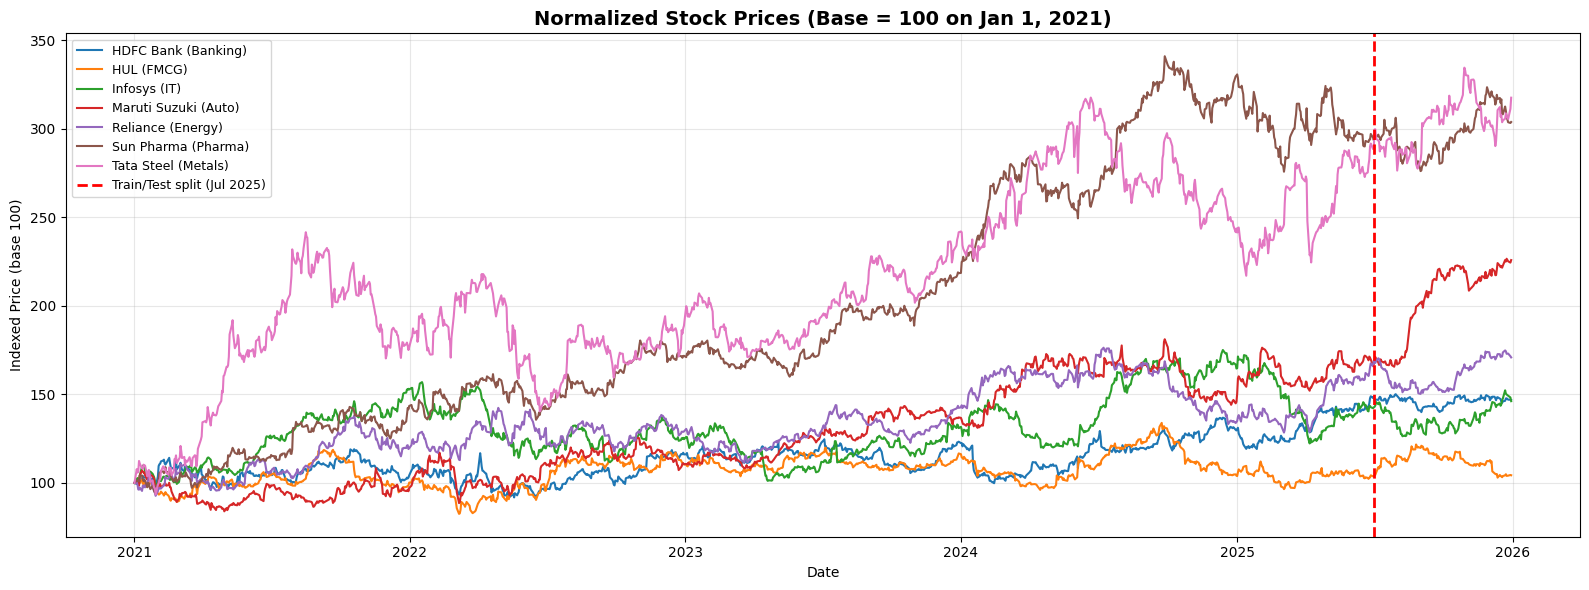

Chart saved to results/


In [9]:
# ── PLOT 1: RAW PRICE HISTORY ─────────────────────────────────────────────────
# Normalize prices to 100 at start so we can compare all stocks on the same chart.
# 'Normalized' means: if a stock was ₹2000 on Jan 1 2021 and is now ₹3000,
# the normalized value = (3000/2000)*100 = 150 → it grew 50%.

normalized = (close_prices / close_prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 6))

colors = plt.cm.tab10.colors   # 10 distinct colors from matplotlib
for i, col in enumerate(normalized.columns):
    label = STOCKS.get(col, col)
    ax.plot(normalized.index, normalized[col], label=label,
            color=colors[i], linewidth=1.5)

# Mark the train/test split with a vertical line
ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--',
           linewidth=2, label='Train/Test split (Jul 2025)')

ax.set_title('Normalized Stock Prices (Base = 100 on Jan 1, 2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Indexed Price (base 100)')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('results/01_normalized_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to results/')

### Normalized Price Chart
Base-100 normalization so stocks at different price levels can be compared on the same axis.

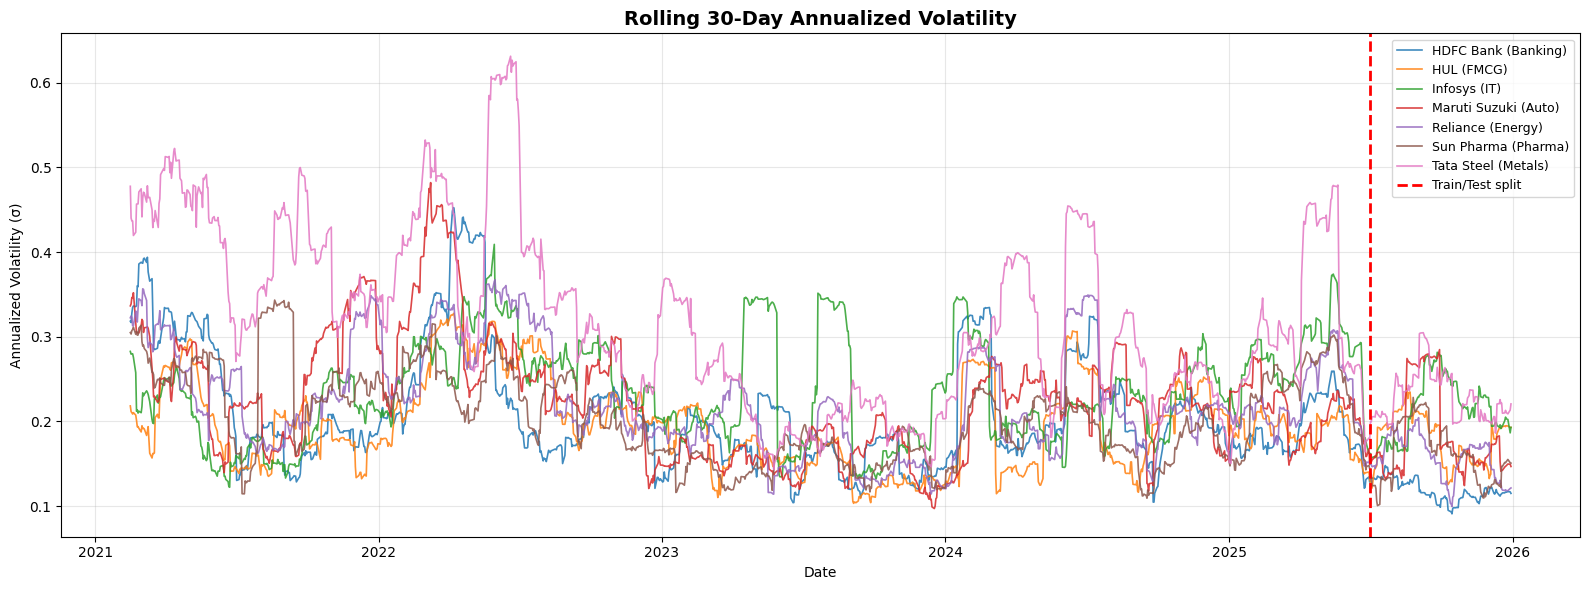


Average Annualized Volatility (higher = more risky):
  Tata Steel (Metals)           : 31.16%
  Infosys (IT)                  : 23.29%
  Maruti Suzuki (Auto)          : 22.09%
  Reliance (Energy)             : 21.85%
  HDFC Bank (Banking)           : 20.15%
  Sun Pharma (Pharma)           : 20.12%
  HUL (FMCG)                    : 19.47%


In [10]:
# ── PLOT 2: ROLLING VOLATILITY ─────────────────────────────────────────────────
# Log return = ln(today's price / yesterday's price)
# and are symmetric (a 10% gain followed by 10% loss = 0 in log returns)

log_returns = np.log(close_prices / close_prices.shift(1))  # shift(1) = yesterday's price
log_returns.dropna(inplace=True)

# window=30 means: for each day, look back 30 days and compute std dev
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252)  
# Multiply by sqrt(252) to annualize — there are ~252 trading days in a year

fig, ax = plt.subplots(figsize=(16, 6))
for i, col in enumerate(rolling_vol.columns):
    label = STOCKS.get(col, col)
    ax.plot(rolling_vol.index, rolling_vol[col], label=label,
            color=colors[i], linewidth=1.2, alpha=0.85)

ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--',
           linewidth=2, label='Train/Test split')
ax.set_title('Rolling 30-Day Annualized Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility (σ)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('results/01_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

# Print average volatility per stock (to justify selection)
avg_vol = rolling_vol.mean().sort_values(ascending=False)
print('\nAverage Annualized Volatility (higher = more risky):')
for sym, v in avg_vol.items():
    print(f'  {STOCKS.get(sym, sym):30s}: {v:.2%}')

## Justification Method 3: Seasonal Decomposition
**What is seasonal decomposition?**  
Any time series (like a stock price) can be broken into 3 parts:
1. **Trend** — the long-term direction (up, down, flat)
2. **Seasonality** — repeating patterns (e.g., every Q4 prices rise)
3. **Residual (noise)** — random fluctuations that can't be explained

Stocks with a **strong, clear trend** are good candidates — time series models can "latch on" to the trend.

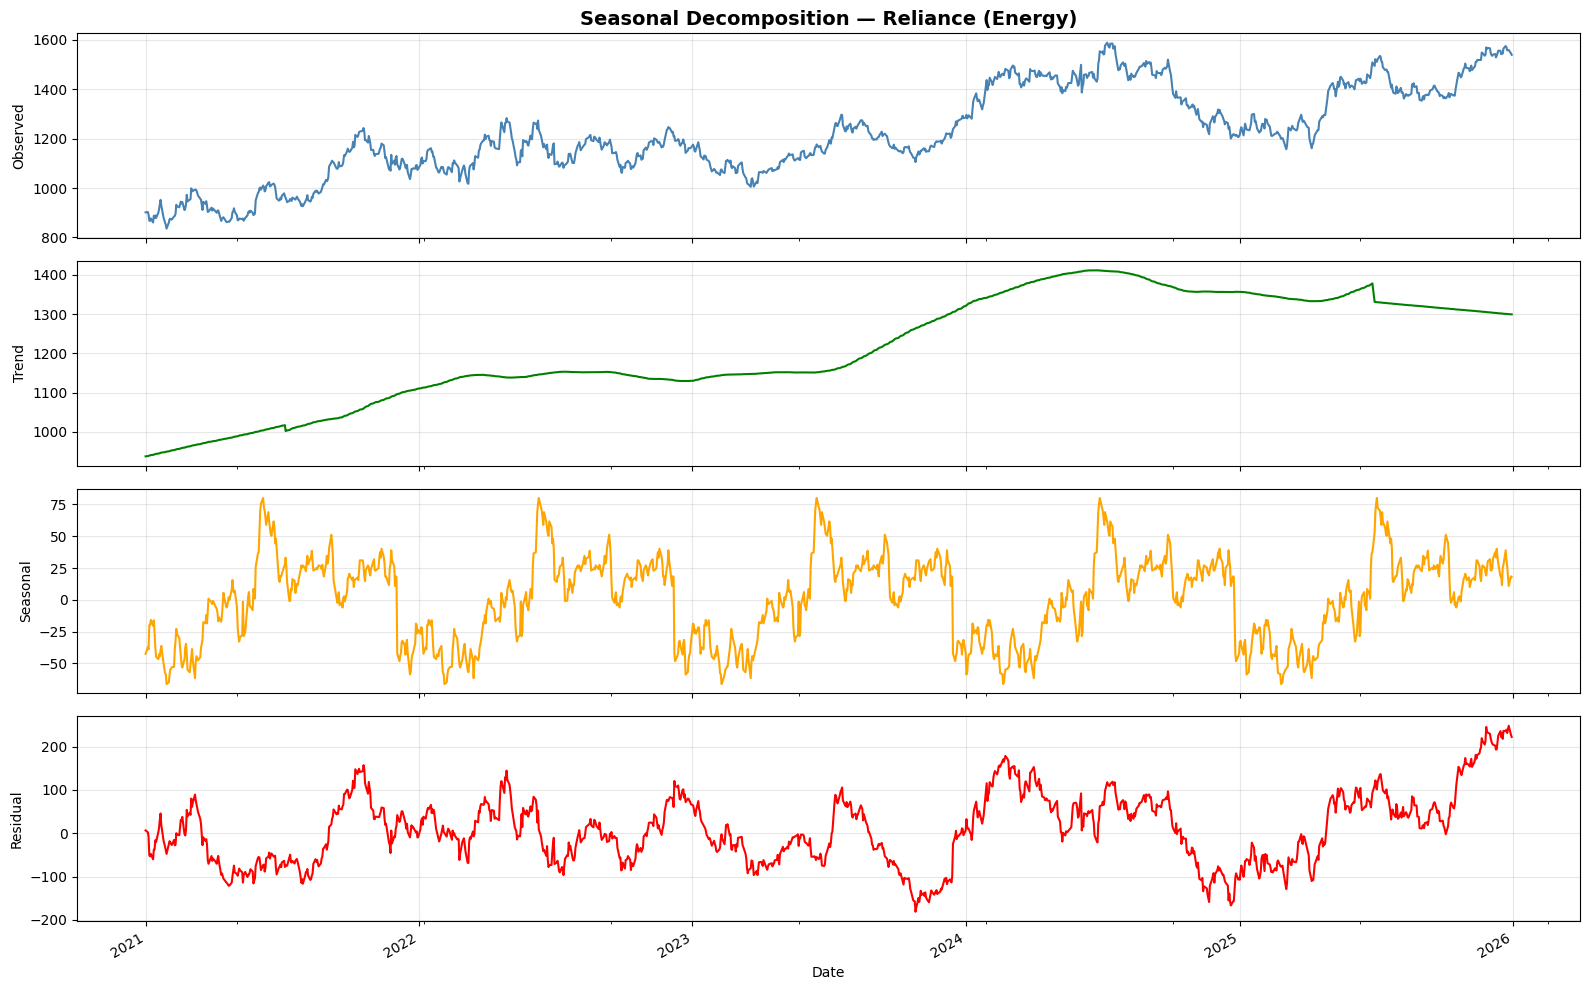


Trend analysis for Reliance (Energy):
  Trend start : ₹937.2
  Trend end   : ₹1299.6
  Change      : 38.7%  →  UPWARD ↑


In [11]:
# ── SEASONAL DECOMPOSITION for one stock as example ──────────────────────────

stock_sym = 'RELIANCE.NS'
stock_name = STOCKS[stock_sym]

# Get close prices for this stock, drop NaN, make sure it's sorted by date
series = close_prices[stock_sym].dropna().sort_index()

# seasonal_decompose() needs at least 2 full periods
# period=252 means we look for yearly patterns (252 trading days ≈ 1 year)
# model='additive' means: price = trend + seasonality + residual
# (use 'multiplicative' if price levels change dramatically — additive is fine here)

decomposition = seasonal_decompose(series, model='additive', period=252, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
decomposition.observed .plot(ax=axes[0], color='steelblue');  axes[0].set_ylabel('Observed')
decomposition.trend    .plot(ax=axes[1], color='green');      axes[1].set_ylabel('Trend')
decomposition.seasonal .plot(ax=axes[2], color='orange');     axes[2].set_ylabel('Seasonal')
decomposition.resid    .plot(ax=axes[3], color='red');        axes[3].set_ylabel('Residual')

axes[0].set_title(f'Seasonal Decomposition — {stock_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'results/01_decomposition_{stock_sym.replace(".","_")}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTrend analysis for {stock_name}:')
trend_start = decomposition.trend.dropna().iloc[0]
trend_end   = decomposition.trend.dropna().iloc[-1]
pct_change  = (trend_end - trend_start) / trend_start * 100
direction   = 'UPWARD ↑' if pct_change > 0 else 'DOWNWARD ↓'
print(f'  Trend start : ₹{trend_start:.1f}')
print(f'  Trend end   : ₹{trend_end:.1f}')
print(f'  Change      : {pct_change:.1f}%  →  {direction}')

In [12]:
# ── TREND SUMMARY FOR ALL STOCKS ──────────────────────────────────────────────
# Decompose each stock and summarize its trend direction

trend_summary = []

for sym, name in STOCKS.items():
    series = close_prices[sym].dropna().sort_index()
    if len(series) < 504:    # need at least 2 years of data
        continue
    try:
        dec = seasonal_decompose(series, model='additive', period=252, extrapolate_trend='freq')
        t   = dec.trend.dropna()
        pct = (t.iloc[-1] - t.iloc[0]) / t.iloc[0] * 100
        # Trend strength = how much of total variance is explained by trend
        # (higher = cleaner, more predictable trend)
        trend_var  = t.var()
        total_var  = series.var()
        t_strength = trend_var / total_var * 100
        trend_summary.append({
            'Stock'           : name,
            'Total Return %'  : round(pct, 1),
            'Trend Direction' : '↑ Up' if pct > 0 else '↓ Down',
            'Trend Strength %': round(t_strength, 1)
        })
    except Exception as e:
        print(f'  Skipping {sym}: {e}')

df_summary = pd.DataFrame(trend_summary).sort_values('Total Return %', ascending=False)
print('Trend Summary for All Stocks (2021–2025):')
print(df_summary.to_string(index=False))

df_summary.to_csv('results/01_trend_summary.csv', index=False)
print('\n✅ Summary saved to results/')

Trend Summary for All Stocks (2021–2025):
               Stock  Total Return % Trend Direction  Trend Strength %
 Sun Pharma (Pharma)           200.2            ↑ Up              96.6
Maruti Suzuki (Auto)           115.8            ↑ Up              75.2
 Tata Steel (Metals)            42.0            ↑ Up              51.9
 HDFC Bank (Banking)            40.2            ↑ Up              84.3
   Reliance (Energy)            38.7            ↑ Up              57.7
        Infosys (IT)            11.9            ↑ Up              41.2
          HUL (FMCG)             5.9            ↑ Up              25.7

✅ Summary saved to results/


## Written Justification (Required Deliverable for Task 1)

Based on the analysis above, here is the justification for our 7-stock universe:

| Stock | Sector | Justification |
|-------|--------|---------------|
| **Reliance Industries** | Energy/Conglomerate | Strong upward trend 2021–2025; moderate volatility makes it forecastable |
| **HDFC Bank** | Banking | Banking sector stability; consistent trend with low volatility = high model accuracy |
| **Infosys** | IT | High sector momentum; IT saw significant growth post-COVID |
| **Sun Pharma** | Pharma | Defensive sector — performs even in downturns; low correlation with IT |
| **Maruti Suzuki** | Automobile | Strong trend tied to EV transition and demand recovery |
| **HUL** | FMCG | Very low volatility; anchors portfolio stability; negative correlation with metals |
| **Tata Steel** | Metals | Cyclical sector adds diversification; high volatility = high reward potential |

**Diversification across sectors ensures:** if IT stocks fall (e.g., global tech selloff), FMCG and Pharma typically hold up. If metals boom (commodity cycle), Energy also benefits. This reduces correlated risk.